# Aufgabe 3 - Tiefe Einblicke ins Institut: Reloaded

Den Code immer nachvollziehbar kommentieren! Bitte beachtet, dass das Notebook von Anfang bis Ende ohne Fehler durchlaufen muss und dass die requirements.txt Datei aktualisiert wird. 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F  
import torchvision.transforms as T
import torch.optim as optim
from torchvision.io import read_image
from torch.utils.data import DataLoader
from torch.utils.data import Dataset

import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [58]:
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Teilaufgabe a): Trainings-, Test-und Validierungsdatenset

In [59]:
rooms = ['Flur', 'Labor', 'Professorenbuero', 'Teekueche']
training_path_list = [f'Bilder/{room}/{room}{n}.jpg' for room in rooms for n in range(1,16)]  # ["./pfad/zu/bildA.png","./pfad/zu/bildB.png",...] -- 15 Bilder je Klasse
validation_path_list = [f'Bilder/{room}/{room}{n}.jpg' for room in rooms for n in range(16, 21)] # ["./pfad/zu/bildZ.png","./pfad/zu/bildY.png",...] -- 5 Bilder je Klasse
test_path_list = [f'Bilder/{room}/{room}{n}.jpg' for room in rooms for n in range(21, 26)] # ["./pfad/zu/bildC.png","./pfad/zu/bildD.png",...] -- 5 Bilder je Klasse


## Teilaufgabe b): CNN definieren und implementieren

In [60]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # 224 x 224
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 112 x 112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 56 x 56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 28 x 28

            # Mittelwert über die komplette Feature Map
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Architektur

Das Netzwerk besteht aus drei Convolution-Blöcken mit 3×3-Kerneln und ReLU-Aktivierungsfunktionen, um Bildmerkmale wie Kanten, Texturen und Formen zu extrahieren.
Nach jeder Faltung reduziert eine MaxPooling-Schicht die Auflösung der Feature Maps, wodurch der Rechenaufwand sinkt und das Netzwerk robuster gegenüber kleinen Bildverschiebungen wird.
Die Anzahl der Feature Maps wird schrittweise von 16 über 32 auf 64 erhöht, sodass in tieferen Schichten komplexere Merkmale gelernt werden können.
Vor der Klassifikation reduziert ein Adaptive Average Pooling jede Feature Map auf einen einzelnen Wert und verringert dadurch die Anzahl der trainierbaren Parameter sowie die Gefahr des Overfittings.
Zusätzlich wird ein Dropout mit einer Wahrscheinlichkeit von 0.5 eingesetzt, um die Generalisierungsfähigkeit des Modells zu verbessern.
Die abschließende Fully-Connected-Schicht ordnet die extrahierten Merkmale einer der vier Klassen zu.

## Teilaufgabe c): Training und Test mit CNN

Datenset-Klasse um mit Pytorch Bilder zu laden. 

Input sind: 
- Liste mit Pfaden zu Bildern
- Liste mit dazugehörigen Labels (numerisch darstellen!) 
- Transformation der Bilder


In [61]:
class ROBDataset(Dataset):
    def __init__(self, img_path_list, img_labels, transform=None):
        # Pfade zu den Bildern als list
        self.img_path_list = img_path_list
        
        # Dazugehörige Labels zu den Bildern als list
        self.img_labels = img_labels
        
        # Transformations der Bilder
        self.transform = transform

    def __len__(self):
        return len(self.img_path_list)

    def __getitem__(self, idx):
        # Bild laden
        img_path = self.img_path_list[idx]
        image = read_image(img_path)
        
        # Label laden
        label = self.img_labels[idx]
        
        # Transformieren
        if self.transform:
            image = self.transform(image)
            
        return image.float(), int(label)

Trainingsiteration über alle Bilder.

Inputs sind:
- Pytorch dataloader Object über das iteriert wird
- bool do_backprob Parameter um Backpropagation durchzuführen oder nicht

In [62]:
# Iterating over the entire data set once
def run_iteration(dataloader, do_backprob=True):
    global net, optimizer, criterion
    loss_iter = []
    acc_iter = []
    for batch_x, batch_y in dataloader:
        # To device
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        # zero the parameter gradients
        optimizer.zero_grad()
        
        # forward + backward + optimize
        y_predict = net(batch_x)
        loss = criterion(y_predict, batch_y)
        if do_backprob:
            loss.backward()
            optimizer.step()

        # statistics
        loss_iter.append(loss.detach().cpu().numpy())
        
        _, predicted = torch.max(torch.softmax(y_predict, dim=1),1)
        
        acc_iter.append(accuracy_score(batch_y.detach().cpu().numpy(), 
                                       predicted.detach().cpu().numpy()))
    
    return np.mean(loss_iter), np.mean(acc_iter)

Komplette Durchführung eines Trainings
Die Variablen y_train, y_val und y_test müssen noch gesetzt werden. Diese Listen beinhalten die entsprechenden Labels als numerische Darstellung.

Running on  cpu

Started Training
Epoch 1 from 100
	Train Loss	 1.4261228
	Train Acc.	 0.25
	Val Loss	 1.3883196
	Val Acc.	 0.25
Epoch 2 from 100
	Train Loss	 1.37826
	Train Acc.	 0.23333333333333334
	Val Loss	 1.3808815
	Val Acc.	 0.3
Epoch 3 from 100
	Train Loss	 1.3779914
	Train Acc.	 0.3
	Val Loss	 1.377286
	Val Acc.	 0.25
Epoch 4 from 100
	Train Loss	 1.3671483
	Train Acc.	 0.26666666666666666
	Val Loss	 1.3665063
	Val Acc.	 0.3
Epoch 5 from 100
	Train Loss	 1.3475094
	Train Acc.	 0.35
	Val Loss	 1.353866
	Val Acc.	 0.3
Epoch 6 from 100
	Train Loss	 1.3482887
	Train Acc.	 0.3333333333333333
	Val Loss	 1.3258717
	Val Acc.	 0.4
Epoch 7 from 100
	Train Loss	 1.328556
	Train Acc.	 0.35
	Val Loss	 1.3055714
	Val Acc.	 0.25
Epoch 8 from 100
	Train Loss	 1.3258051
	Train Acc.	 0.3
	Val Loss	 1.2789509
	Val Acc.	 0.4
Epoch 9 from 100
	Train Loss	 1.3240571
	Train Acc.	 0.36666666666666664
	Val Loss	 1.2504976
	Val Acc.	 0.4
Epoch 10 from 100
	Train Loss	 1.3411769
	Train Acc.	 0.3
	Val Lo

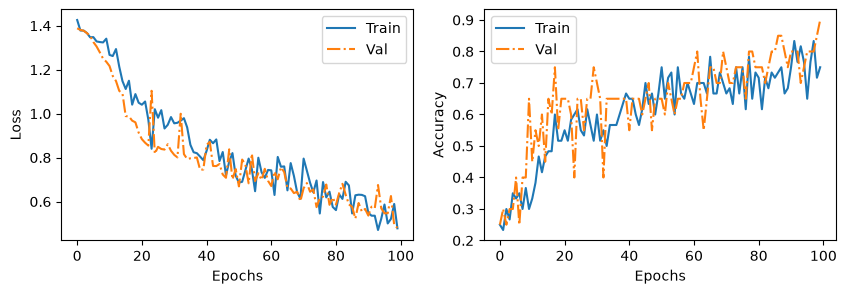

In [63]:
# Label pro Klasse
room_to_label = {'Flur': 0, 'Labor': 1, 'Professorenbuero': 2, 'Teekueche': 3}


y_train = [room_to_label[path.split('/')[1]] for path in training_path_list]
y_val = [room_to_label[path.split('/')[1]] for path in validation_path_list]
y_test = [room_to_label[path.split('/')[1]] for path in test_path_list]

# Training settings - bei Bedarf anpassbar
max_epoch = 100
batch_size = 4
lr = 0.001


# Transformations for dataloader
t_train = T.Compose([T.ToPILImage(),
                    T.ToTensor(),
                    T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])
t_val = T.Compose([T.ToPILImage(),
                   T.ToTensor(),
                   T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])
t_test = T.Compose([T.ToPILImage(),
                   T.ToTensor(),
                   T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])

# Where to do calculations
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Running on ",device)

# Training Data, NOTE: y_train labels need to be set
dataset_train = ROBDataset(training_path_list, y_train, transform=t_train)
dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

# Validation Data, NOTE: y_val labels need to be set
dataset_val = ROBDataset(validation_path_list, y_val, transform=t_val) # TODO Template anpassen! (t_val statt t_train)
dataloader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)

# Test Data, NOTE: y_test labels need. to be set
dataset_test = ROBDataset(test_path_list, y_test,transform=t_test)
dataloader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

# Network, optimizer and loss initialisation
net = Net()
net.to(device)
optimizer = optim.Adam(net.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Los geht's mit Training
print("\nStarted Training")
# Training loss and accuracy per epoch
train_loss_epoch = []
train_acc_epoch = []
# Validation loss and accuracy per epoch
val_loss_epoch = []
val_acc_epoch = []

for epoch in range(0,max_epoch):  # loop over the dataset multiple times
    print(f"Epoch {epoch+1} from {max_epoch}")
    
    ### TRAINING ###
    net.train()
    train_loss_iter, train_acc_iter = run_iteration(dataloader_train)

    # Logging loss and accuarcy of training iteration
    train_loss_epoch.append(train_loss_iter)
    train_acc_epoch.append(train_acc_iter)
    print("\tTrain Loss\t",train_loss_iter)
    print("\tTrain Acc.\t",train_acc_iter)
    
    ### VALIDATION ###
    with torch.no_grad():  # No gradient calculation
        net.eval()
        val_loss_iter, val_acc_iter = run_iteration(dataloader_val,do_backprob=False)

        # Logging loss and accuarcy of validation iteration
        val_loss_epoch.append(val_loss_iter)
        val_acc_epoch.append(val_acc_iter)
        print("\tVal Loss\t",val_loss_iter)
        print("\tVal Acc.\t",val_acc_iter)

# Plotting results
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(10,3))
ax[0].plot(train_loss_epoch,label="Train")
ax[0].plot(val_loss_epoch,label="Val",linestyle="-.")
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epochs')
ax[0].legend()

ax[1].plot(train_acc_epoch,label="Train")
ax[1].plot(val_acc_epoch,label="Val",linestyle="-.")
ax[1].set_ylabel('Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].legend()
plt.savefig("loss_augmentation.png",format="png",bbox_inches="tight")
plt.show()

In [64]:
#Vorhersagen (y_pred) über das trainierte Netz generieren
y_pred = []
with torch.no_grad():
    for batch_x, batch_y in dataloader_test:
        batch_x = batch_x.to(device)
        y_predict = net(batch_x)
        # Klasse mit der höchsten Wahrscheinlichkeit ermitteln
        _, predicted = torch.max(torch.softmax(y_predict, dim=1), 1)
        y_pred.extend(predicted.cpu().numpy())


In [65]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1       :", f1_score(y_test, y_pred, average="weighted"))


Accuracy : 0.75
Precision: 0.7660714285714285
Recall   : 0.75
F1       : 0.7472222222222221


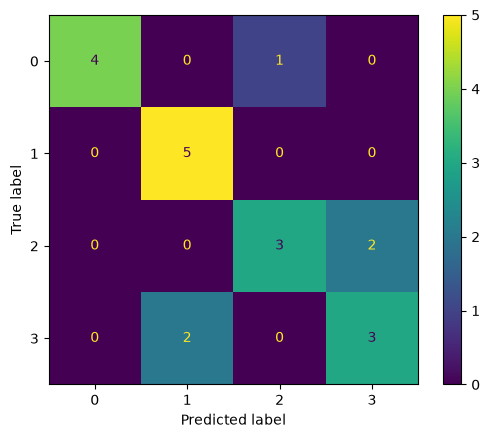

In [66]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.show()

## Teilaufgabe d): Augmentierung

Wir spiegeln zufällig horizontal und rotieren zufällig um bis zu 15 Grad.
Außerdem passen wir die Farben leicht zufällig an.
Das bildet unterschiedliche Standpunkte, Kamerawinkel und Lichtverhältnisse ab.
Die Datenaugmentation führte in diesem Fall zu keiner bzw. nur einer geringen Verbesserung.
Aufgrund des kleinen Datensatzes und der bereits ähnlichen Aufnahmen konnten die zusätzlichen Transformationen nur begrenzt zur Generalisierung beitragen.

Running on  cpu

Started Training
Epoch 1 from 100
	Train Loss	 1.3986183
	Train Acc.	 0.18333333333333332
	Val Loss	 1.3841605
	Val Acc.	 0.25
Epoch 2 from 100
	Train Loss	 1.3905847
	Train Acc.	 0.2
	Val Loss	 1.3846447
	Val Acc.	 0.25
Epoch 3 from 100
	Train Loss	 1.3799878
	Train Acc.	 0.2833333333333333
	Val Loss	 1.384896
	Val Acc.	 0.35
Epoch 4 from 100
	Train Loss	 1.3804059
	Train Acc.	 0.35
	Val Loss	 1.3830683
	Val Acc.	 0.4
Epoch 5 from 100
	Train Loss	 1.3757491
	Train Acc.	 0.3333333333333333
	Val Loss	 1.3814489
	Val Acc.	 0.3
Epoch 6 from 100
	Train Loss	 1.3599136
	Train Acc.	 0.36666666666666664
	Val Loss	 1.3749132
	Val Acc.	 0.25
Epoch 7 from 100
	Train Loss	 1.3932937
	Train Acc.	 0.26666666666666666
	Val Loss	 1.3709742
	Val Acc.	 0.3
Epoch 8 from 100
	Train Loss	 1.3712202
	Train Acc.	 0.23333333333333334
	Val Loss	 1.3634803
	Val Acc.	 0.25
Epoch 9 from 100
	Train Loss	 1.3748866
	Train Acc.	 0.4
	Val Loss	 1.360364
	Val Acc.	 0.35
Epoch 10 from 100
	Train Loss	

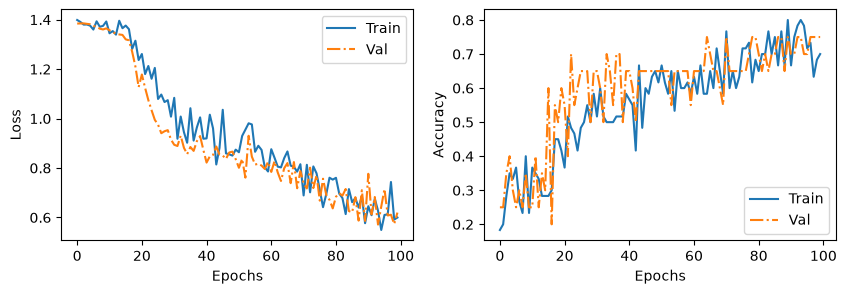

In [67]:
room_to_label = {'Flur': 0, 'Labor': 1, 'Professorenbuero': 2, 'Teekueche': 3}

y_train = [room_to_label[path.split('/')[1]] for path in training_path_list]
y_val = [room_to_label[path.split('/')[1]] for path in validation_path_list]
y_test = [room_to_label[path.split('/')[1]] for path in test_path_list]

# Training settings - bei Bedarf anpassbar
max_epoch = 100
batch_size = 4
lr = 0.001


# Transformations for dataloader
t_train = T.Compose([T.ToPILImage(),
                    T.ToTensor(),
                    T.RandomHorizontalFlip(p=0.5), # Zufälliges horizontales Spiegeln
                    T.RandomRotation(degrees=15), # Zufällige Drehung um bis zu 15 Grad
                    T.ColorJitter( # Zufällige Farbanpassungen
                        brightness=0.2,
                        contrast=0.2,
                        saturation=0.2
                    ),
                    T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])
t_val = T.Compose([T.ToPILImage(),
                   T.ToTensor(),
                   T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])
t_test = T.Compose([T.ToPILImage(),
                   T.ToTensor(),
                   T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])

# Where to do calculations
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Running on ",device)

# Training Data, NOTE: y_train labels need to be set
dataset_train = ROBDataset(training_path_list, y_train, transform=t_train)
dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

# Validation Data, NOTE: y_val labels need to be set
dataset_val = ROBDataset(validation_path_list, y_val, transform=t_val)
dataloader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)

# Test Data, NOTE: y_test labels need. to be set
dataset_test = ROBDataset(test_path_list, y_test,transform=t_test)
dataloader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

# Network, optimizer and loss initialisation
net = Net()
net.to(device)
optimizer = optim.Adam(net.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Los geht's mit Training
print("\nStarted Training")
# Training loss and accuracy per epoch
train_loss_epoch = []
train_acc_epoch = []
# Validation loss and accuracy per epoch
val_loss_epoch = []
val_acc_epoch = []

for epoch in range(0,max_epoch):  # loop over the dataset multiple times
    print(f"Epoch {epoch+1} from {max_epoch}")
    
    ### TRAINING ###
    net.train()
    train_loss_iter, train_acc_iter = run_iteration(dataloader_train)

    # Logging loss and accuarcy of training iteration
    train_loss_epoch.append(train_loss_iter)
    train_acc_epoch.append(train_acc_iter)
    print("\tTrain Loss\t",train_loss_iter)
    print("\tTrain Acc.\t",train_acc_iter)
    
    ### VALIDATION ###
    with torch.no_grad():  # No gradient calculation
        net.eval()
        val_loss_iter, val_acc_iter = run_iteration(dataloader_val,do_backprob=False)

        # Logging loss and accuarcy of validation iteration
        val_loss_epoch.append(val_loss_iter)
        val_acc_epoch.append(val_acc_iter)
        print("\tVal Loss\t",val_loss_iter)
        print("\tVal Acc.\t",val_acc_iter)

# Plotting results
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(10,3))
ax[0].plot(train_loss_epoch,label="Train")
ax[0].plot(val_loss_epoch,label="Val",linestyle="-.")
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epochs')
ax[0].legend()

ax[1].plot(train_acc_epoch,label="Train")
ax[1].plot(val_acc_epoch,label="Val",linestyle="-.")
ax[1].set_ylabel('Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].legend()
plt.savefig("loss_augmentation.png",format="png",bbox_inches="tight")
plt.show()

In [68]:
#Vorhersagen (y_pred) über das trainierte Netz generieren
y_pred = []
with torch.no_grad():
    for batch_x, batch_y in dataloader_test:
        batch_x = batch_x.to(device)
        y_predict = net(batch_x)
        # Klasse mit der höchsten Wahrscheinlichkeit ermitteln
        _, predicted = torch.max(torch.softmax(y_predict, dim=1), 1)
        y_pred.extend(predicted.cpu().numpy())


In [69]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1       :", f1_score(y_test, y_pred, average="weighted"))


Accuracy : 0.8
Precision: 0.84375
Recall   : 0.8
F1       : 0.7964743589743589


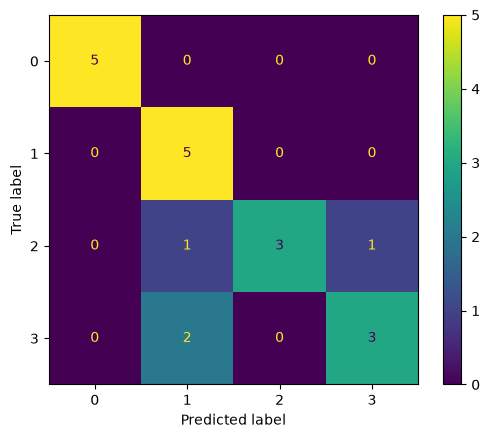

In [70]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.show()

## Teilaufgabe e): Early Stopping

Running on  cpu

Started Training
Epoch 1 from 100
	Train Loss	 1.390648
	Train Acc.	 0.2833333333333333
	Val Loss	 1.384543
	Val Acc.	 0.4
Epoch 2 from 100
	Train Loss	 1.3948321
	Train Acc.	 0.16666666666666666
	Val Loss	 1.3838049
	Val Acc.	 0.25
Epoch 3 from 100
	Train Loss	 1.3833176
	Train Acc.	 0.2833333333333333
	Val Loss	 1.3827083
	Val Acc.	 0.45
Epoch 4 from 100
	Train Loss	 1.3870609
	Train Acc.	 0.25
	Val Loss	 1.3781046
	Val Acc.	 0.25
Epoch 5 from 100
	Train Loss	 1.3904097
	Train Acc.	 0.18333333333333332
	Val Loss	 1.3729274
	Val Acc.	 0.35
Epoch 6 from 100
	Train Loss	 1.3850464
	Train Acc.	 0.21666666666666667
	Val Loss	 1.3681127
	Val Acc.	 0.4
Epoch 7 from 100
	Train Loss	 1.3786675
	Train Acc.	 0.2833333333333333
	Val Loss	 1.3572677
	Val Acc.	 0.4
Epoch 8 from 100
	Train Loss	 1.381726
	Train Acc.	 0.31666666666666665
	Val Loss	 1.3529379
	Val Acc.	 0.5
Epoch 9 from 100
	Train Loss	 1.3342327
	Train Acc.	 0.4666666666666667
	Val Loss	 1.3122113
	Val Acc.	 0.5
Epo

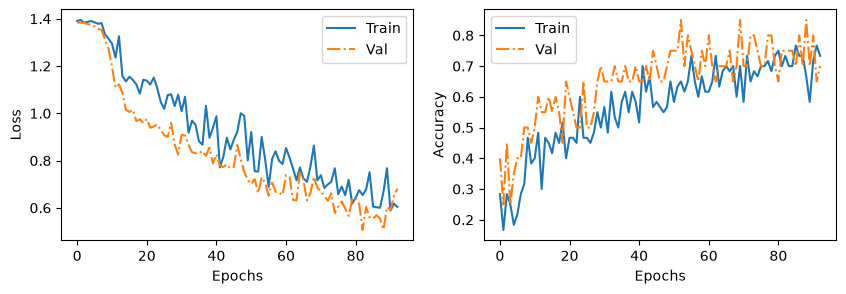

In [75]:
room_to_label = {'Flur': 0, 'Labor': 1, 'Professorenbuero': 2, 'Teekueche': 3}

y_train = [room_to_label[path.split('/')[1]] for path in training_path_list]
y_val = [room_to_label[path.split('/')[1]] for path in validation_path_list]
y_test = [room_to_label[path.split('/')[1]] for path in test_path_list]

# Training settings - bei Bedarf anpassbar
max_epoch = 100
batch_size = 4
lr = 0.001

# Early Stopping
patience = 10 # Wie viele Epochen das Netz ohne Verbesserung weiterlaufen darf
best_val_loss = np.inf # Startwert für den besten Fehler
patience_counter = 0 # Zähler für die Epochen ohne Veränderung von Loss
best_model_wts = None # Bestes Modell bisher


# Transformations for dataloader
t_train = T.Compose([T.ToPILImage(),
                    T.RandomHorizontalFlip(p=0.5), # Zufälliges horizontales Spiegeln
                    T.RandomRotation(degrees=15), # Zufällige Drehung um bis zu 15 Grad
                    T.ColorJitter( # Zufällige Farbanpassungen
                        brightness=0.2,
                        contrast=0.2,
                        saturation=0.2
                    ),
                    T.ToTensor(),
                    T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])
t_val = T.Compose([T.ToPILImage(),
                   T.ToTensor(),
                   T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])
t_test = T.Compose([T.ToPILImage(),
                   T.ToTensor(),
                   T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])

# Where to do calculations
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Running on ",device)

# Training Data, NOTE: y_train labels need to be set
dataset_train = ROBDataset(training_path_list, y_train, transform=t_train)
dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)

# Validation Data, NOTE: y_val labels need to be set
dataset_val = ROBDataset(validation_path_list, y_val, transform=t_val)
dataloader_val = DataLoader(dataset_val, batch_size=batch_size, shuffle=False)

# Test Data, NOTE: y_test labels need. to be set
dataset_test = ROBDataset(test_path_list, y_test,transform=t_test)
dataloader_test = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

# Network, optimizer and loss initialisation
net = Net()
net.to(device)
optimizer = optim.Adam(net.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

# Los geht's mit Training
print("\nStarted Training")
# Training loss and accuracy per epoch
train_loss_epoch = []
train_acc_epoch = []
# Validation loss and accuracy per epoch
val_loss_epoch = []
val_acc_epoch = []

for epoch in range(0,max_epoch):  # loop over the dataset multiple times
    print(f"Epoch {epoch+1} from {max_epoch}")
    
    ### TRAINING ###
    net.train()
    train_loss_iter, train_acc_iter = run_iteration(dataloader_train)

    # Logging loss and accuarcy of training iteration
    train_loss_epoch.append(train_loss_iter)
    train_acc_epoch.append(train_acc_iter)
    print("\tTrain Loss\t",train_loss_iter)
    print("\tTrain Acc.\t",train_acc_iter)
    
    ### VALIDATION ###
    with torch.no_grad():  # No gradient calculation
        net.eval()
        val_loss_iter, val_acc_iter = run_iteration(dataloader_val,do_backprob=False)

        # Logging loss and accuarcy of validation iteration
        val_loss_epoch.append(val_loss_iter)
        val_acc_epoch.append(val_acc_iter)
        print("\tVal Loss\t",val_loss_iter)
        print("\tVal Acc.\t",val_acc_iter)
    
    ### EARLY STOPPING CHECK ###
    if val_loss_iter < best_val_loss:
        best_val_loss = val_loss_iter
        best_model_wts = {k: v.clone() for k, v in net.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"\tKeine Verbesserung seit {patience_counter}/{patience} Epochen")
        
    if patience_counter >= patience:
        # print(f"Training vorzeitig abgebrochen in Epoche {epoch+1}")
        break

if best_model_wts is not None:
    net.load_state_dict(best_model_wts)

# Plotting results
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(10,3))
ax[0].plot(train_loss_epoch,label="Train")
ax[0].plot(val_loss_epoch,label="Val",linestyle="-.")
ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epochs')
ax[0].legend()

ax[1].plot(train_acc_epoch,label="Train")
ax[1].plot(val_acc_epoch,label="Val",linestyle="-.")
ax[1].set_ylabel('Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].legend()
plt.savefig("loss_augmentation.png",format="png",bbox_inches="tight")
plt.show()

In [72]:
#Vorhersagen (y_pred) über das trainierte Netz generieren
y_pred = []
with torch.no_grad():
    for batch_x, batch_y in dataloader_test:
        batch_x = batch_x.to(device)
        y_predict = net(batch_x)
        # Klasse mit der höchsten Wahrscheinlichkeit ermitteln
        _, predicted = torch.max(torch.softmax(y_predict, dim=1), 1)
        y_pred.extend(predicted.cpu().numpy())


In [73]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1       :", f1_score(y_test, y_pred, average="weighted"))


Accuracy : 0.7
Precision: 0.7104166666666666
Recall   : 0.7
F1       : 0.683974358974359


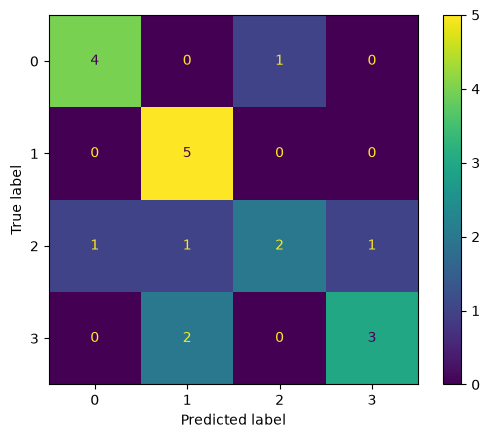

In [74]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

plt.show()

### Vergleich

In unserem Fall gab es beim Early-Stopping keine Verbesserung.
Die Acuracy, sowie der Recall, haben sich von 0.8 auf 0.7 verschlechtert, die Precision von 0.84 auf 0.71.
Der F1-Score hat sich von 0.80 auf 0.68 verschlechtert.
